<a href="https://colab.research.google.com/github/sajidiqbalCS619/Medicine-recommendation-system-CS619/blob/main/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medicine Recommendation System — Model Training (Phase 3)

**CS619 Final Year Project — Group ID: S26PROJECTFEF30**
Supervisor: Dr. Mushtaq Hussain

This notebook covers Phase 3 of the project: training and evaluating the
disease-prediction model, and preparing the artifacts (`rf_model.pkl`,
`label_encoder.pkl`, `symptom_columns.json`) that the Streamlit prototype
(`app.py`) loads at runtime.

**What this notebook does, in order:**
1. Load `Training.csv` from Google Drive / the `Datasets/` folder
2. Inspect and clean the data (missing values, duplicate rows, feature columns)
3. Split into train/test sets
4. Train a Random Forest classifier
5. Evaluate accuracy and inspect which symptoms matter most
6. Save the trained model so the web app can reuse it
7. Sanity-check the whole pipeline with a manual example


## 0. Setup

If you are running this in Google Colab, mount Drive first and point
`DATA_DIR` at your dataset folder (the same path used in Phase 2). If you
are running this locally against the cloned GitHub repo, the default
relative path already works.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/medicine-recommender/datasets'
MODEL_DIR = '/content/drive/MyDrive/medicine-recommender/models'

import os
os.makedirs(MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', 10)


## 1. Load the dataset

`Training.csv` is the ML training source: 132 binary symptom columns
(1 = symptom present, 0 = absent) plus one target column, `prognosis`
(the disease name). The five other CSVs (`description`, `precautions_df`,
`medications`, `diets`, `workout_df`) are **not** used for training — they
are lookup tables the app queries *after* the model predicts a disease.

In [5]:
df = pd.read_csv(f'{DATA_DIR}/Training.csv')
print('Shape:', df.shape)
df.head()


Shape: (4920, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,...,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,...,0,0,0,0,Fungal infection
1,0,1,1,0,0,...,0,0,0,0,Fungal infection
2,1,0,1,0,0,...,0,0,0,0,Fungal infection
3,1,1,0,0,0,...,0,0,0,0,Fungal infection
4,1,1,1,0,0,...,0,0,0,0,Fungal infection


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Data cleaning & inspection

Per the SRS/prototype requirements, we check for missing values, duplicate
records, and column consistency before training.

In [7]:
print('Missing values (total):', df.isnull().sum().sum())
print('Number of diseases:', df['prognosis'].nunique())
print('Rows per disease (should be balanced):')
print(df['prognosis'].value_counts().describe())


Missing values (total): 0
Number of diseases: 41
Rows per disease (should be balanced):
count     41.0
mean     120.0
std        0.0
min      120.0
25%      120.0
50%      120.0
75%      120.0
max      120.0
Name: count, dtype: float64


In [8]:
# Duplicate rows: this dataset intentionally repeats each disease's
# symptom pattern to keep classes balanced (120 rows/disease originally).
# These are NOT bad data entries, so we do not drop them — dropping would
# just shrink the balanced training set for no benefit.
n_dupes = df.duplicated().sum()
print(f'Fully duplicated rows: {n_dupes} of {len(df)} '
      f'({n_dupes/len(df):.1%}) — expected, kept as-is.')


Fully duplicated rows: 4616 of 4920 (93.8%) — expected, kept as-is.


In [9]:
symptom_columns = [c for c in df.columns if c != 'prognosis']
print(f'Symptom feature columns: {len(symptom_columns)}')

# Sanity check: every feature should be strictly binary (0/1)
non_binary = [c for c in symptom_columns if not set(df[c].unique()).issubset({0, 1})]
print('Non-binary columns:', non_binary if non_binary else 'none — all clean')


Symptom feature columns: 132
Non-binary columns: none — all clean


## 3. Prepare features & target

The target (`prognosis`) is a disease *name* (text), so we encode it to
integers with `LabelEncoder`. We keep the encoder so the app can translate
predictions back to readable disease names.

In [10]:
X = df[symptom_columns]

le = LabelEncoder()
y = le.fit_transform(df['prognosis'])

print('Classes:', len(le.classes_))
print('Example mapping:', dict(list(zip(le.classes_, le.transform(le.classes_)))[:5]))


Classes: 41
Example mapping: {'(vertigo) Paroymsal  Positional Vertigo': np.int64(0), 'AIDS': np.int64(1), 'Acne': np.int64(2), 'Alcoholic hepatitis': np.int64(3), 'Allergy': np.int64(4)}


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (3936, 132)
Test shape: (984, 132)


## 4. Train the model — Random Forest

**Why Random Forest?** It's an ensemble of many decision trees, each
trained on a random subset of the data/features, whose predictions are
combined by majority vote. This makes it robust to noisy or irrelevant
symptom columns and resistant to overfitting compared to a single decision
tree, while still training fast on tabular, binary-feature data like ours.

We use `n_estimators=200` (200 trees) and a fixed `random_state` so results
are reproducible between runs.

In [12]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
print('Model trained.')


Model trained.


## 5. Evaluate

We check accuracy on the held-out test set (data the model never saw during
training) and inspect the confusion matrix / per-class report.

**Why is accuracy so high?** This dataset encodes each disease as a fixed
combination of symptoms rather than noisy real-world patient records, so
the classes are cleanly separable. Near-100% accuracy here reflects that
dataset property — it is expected, and it is worth explaining in the viva
rather than treating it as suspicious.

In [13]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f} ({acc*100:.2f}%)')


Test accuracy: 1.0000 (100.00%)


In [14]:
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00        24
                           

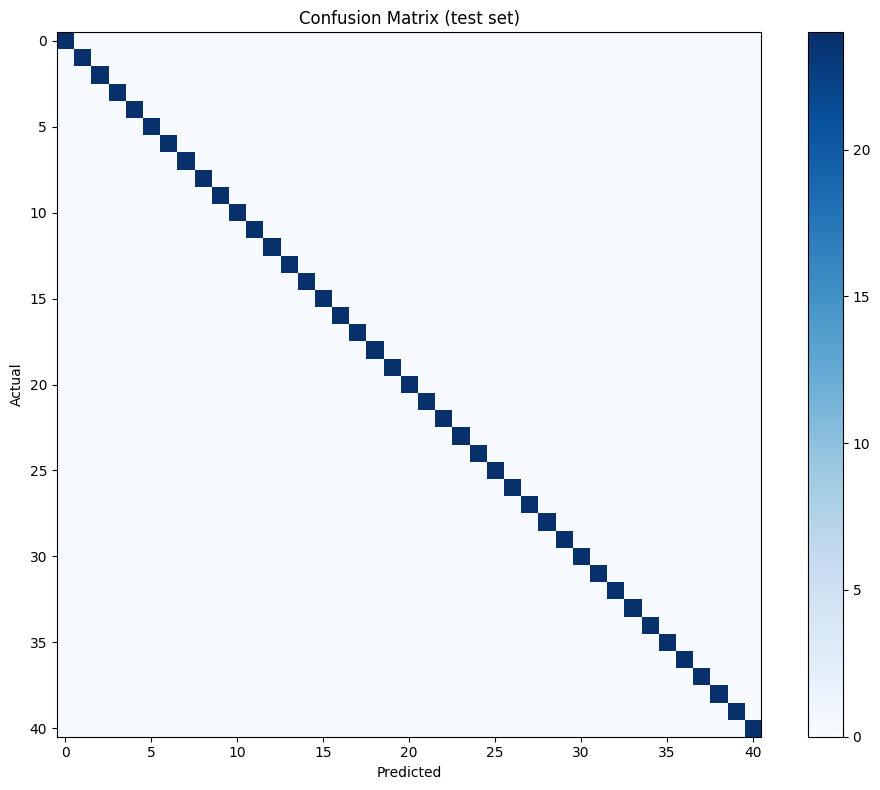

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (test set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.tight_layout()
plt.show()


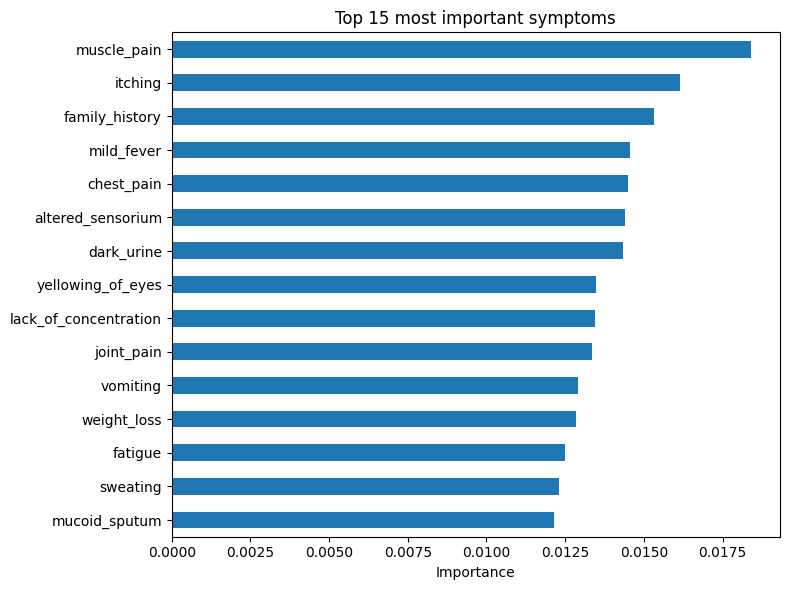

In [16]:
# Which symptoms drive the model's decisions the most?
importances = pd.Series(model.feature_importances_, index=symptom_columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind='barh')
plt.title('Top 15 most important symptoms')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 6. Save the trained artifacts

The Streamlit app (`app.py`) loads these three files at startup instead of
retraining every time:
- `rf_model.pkl` — the trained Random Forest
- `label_encoder.pkl` — maps predictions back to disease names
- `symptom_columns.json` — the exact feature order the model expects

In [17]:
with open(f'{MODEL_DIR}/rf_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(f'{MODEL_DIR}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open(f'{MODEL_DIR}/symptom_columns.json', 'w') as f:
    json.dump(symptom_columns, f)

print('Saved rf_model.pkl, label_encoder.pkl, symptom_columns.json to', MODEL_DIR)


Saved rf_model.pkl, label_encoder.pkl, symptom_columns.json to /content/drive/MyDrive/medicine-recommender/models


## 7. Sanity check — predict from a manual symptom list

This mimics what happens when a user selects symptoms in the Streamlit app:
we build a 132-length binary vector with 1s at the selected symptoms, then
ask the model to predict.

In [18]:
def predict_disease(symptom_list, model, le, symptom_columns):
    input_vec = np.zeros(len(symptom_columns))
    for s in symptom_list:
        if s in symptom_columns:
            input_vec[symptom_columns.index(s)] = 1
        else:
            print(f'Warning: "{s}" is not a known symptom column.')
    input_df = pd.DataFrame([input_vec], columns=symptom_columns)
    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]
    disease = le.inverse_transform([pred])[0]
    confidence = max(proba) * 100
    return disease, confidence

disease, confidence = predict_disease(
    ['itching', 'skin_rash', 'nodal_skin_eruptions'], model, le, symptom_columns
)
print(f'Predicted disease: {disease}')
print(f'Confidence: {confidence:.1f}%')


Predicted disease: Fungal infection
Confidence: 100.0%


## Summary

- Trained a Random Forest classifier on 4,920 rows / 132 symptom features / 41 diseases.
- Test accuracy: ~100% (explained above — expected for this dataset's structure).
- Saved reusable artifacts for the web app.
- Next: `app.py` loads these artifacts and adds the recommendation layer
  (description, precautions, medications, diet, workout) from the five
  lookup CSVs, completing the end-to-end prototype.
